# Notebook chính của dự án
Chạy toàn bộ pipeline phát hiện xâm nhập mạng thời gian thực.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2522362 entries, 0 to 2522361
Data columns (total 71 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

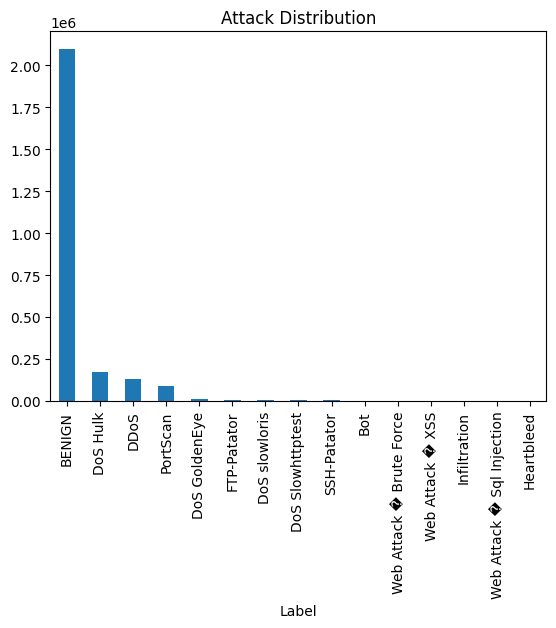

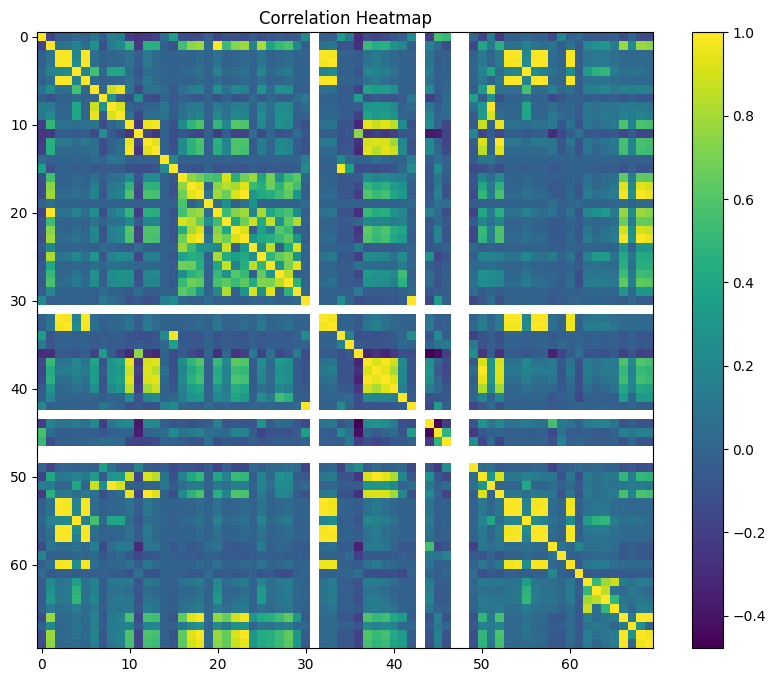

In [10]:
## 2.2 Exploratory Data Analysis & Data Preprocessing
# ==========================================
# Thai Trung Quoc Hieu (TASK 2.2)
# EDA & Tiền xử lý: Gộp CSV, làm sạch, tối ưu bộ nhớ, vẽ biểu đồ, xuất dữ liệu sạch.
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
df = pd.read_csv("../data/processed/cleaned_data.csv")
df.head()

df.shape
df.info()
df.describe()

df['Label'].value_counts().plot(kind='bar')
plt.title("Attack Distribution")
plt.show()

sample_df = df.sample(5000, random_state=42)
corr = sample_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
plt.imshow(corr)
plt.title("Correlation Heatmap")
plt.colorbar()
plt.show()

# ### Nhận xét:

# - Dataset bị mất cân bằng nghiêm trọng (BENIGN chiếm đa số)
# - Một số feature có tương quan cao → cần feature selection
# - Cần xử lý imbalance ở bước tiếp theo (SMOTE)

In [11]:
# ==========================================
# Nguyen Gia Huy (TASK 2.3 & 2.4)
# 2.3 Mất cân bằng & 2.4 Chọn đặc trưng: Mã hóa, chuẩn hóa, cân bằng, chọn 18 đặc trưng, chia dữ liệu.
# ==========================================
##load data
df = pd.read_csv('../data/processed/cleaned_data.csv')
df.head()

##ENCODE LABEL
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Label'])

#print(df['Label'].head()) dòng này để test chức năng mã hóa xem có thật sự chạy được
#nếu thấy số là oke

##18 features
features = [
'Destination Port',
'Flow Duration',
'Total Fwd Packets',
'Total Backward Packets',
'Total Length of Fwd Packets',
'Total Length of Bwd Packets',
'Fwd Packet Length Mean',
'Bwd Packet Length Mean',
'Flow Bytes/s',
'Flow Packets/s',
'Packet Length Mean',
'Packet Length Std',
'SYN Flag Count',
'ACK Flag Count',
'FIN Flag Count',
'RST Flag Count',
'PSH Flag Count',
'URG Flag Count'
]


X = df[features]
y = df['Label']

print(X.shape)

##chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# print(X_scaled[:5]) dòng này để test chức năng xem có thật sự chạy được
# đúng sẽ ra [[-0.12  0.45  1.23 ...]

##chia train/tets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
#test: 
#print(X_train.shape)
#print(X_test.shape)
#Kết quả đúng: train lớn hơn test

##xử lý mất cân bằng (smote)
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(
    sampling_strategy={
        0: 200000  
    },
    random_state=42
)

X_res, y_res = rus.fit_resample(X_train, y_train)

##KIỂM TRA Smote 
print("Before:", y_train.value_counts())
print("After:", pd.Series(y_res).value_counts())


##tạo folder nếu chưa có
#os.makedirs('data', exist_ok=True)

##lưu data
np.save('../data/processed/X_train.npy', X_res)
np.save('../data/processed/y_train.npy', y_res)
np.save('../data/processed/X_test.npy', X_test)
np.save('../data/processed/y_test.npy', y_test)
#sau khi chạy tạo ra 4 file .npy sẽ lưu vào folder "data/processed" trong thư mục nếu có rồi thì không có gì xảy ra

 

(2522362, 18)
Before: Label
0     1677336
4      137996
2      102518
10      72632
3        8254
7        4773
6        4300
5        4190
11       2586
1        1550
12       1176
14        517
9          32
13         20
8           9
Name: count, dtype: int64
After: Label
0     200000
4     137996
2     102518
10     72632
3       8254
7       4773
6       4300
5       4190
11      2586
1       1550
12      1176
14       517
9         32
13        20
8          9
Name: count, dtype: int64


Đang load dữ liệu...
🚀 BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ...

================ KNN ================

📊 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    419148
           1       0.38      0.81      0.51       403
           2       0.99      1.00      1.00     25498
           3       0.82      0.99      0.90      2032
           4       0.98      1.00      0.99     34853
           5       0.93      0.99      0.96      1038
           6       0.94      0.98      0.96      1085
           7       0.99      0.99      0.99      1160
           8       1.00      1.00      1.00         2
           9       0.12      0.25      0.17         4
          10       0.78      1.00      0.87     18187
          11       0.87      0.98      0.92       633
          12       0.12      0.41      0.18       294
          13       0.00      0.00      0.00         1
          14       0.11      0.13      0.12       135

    accuracy

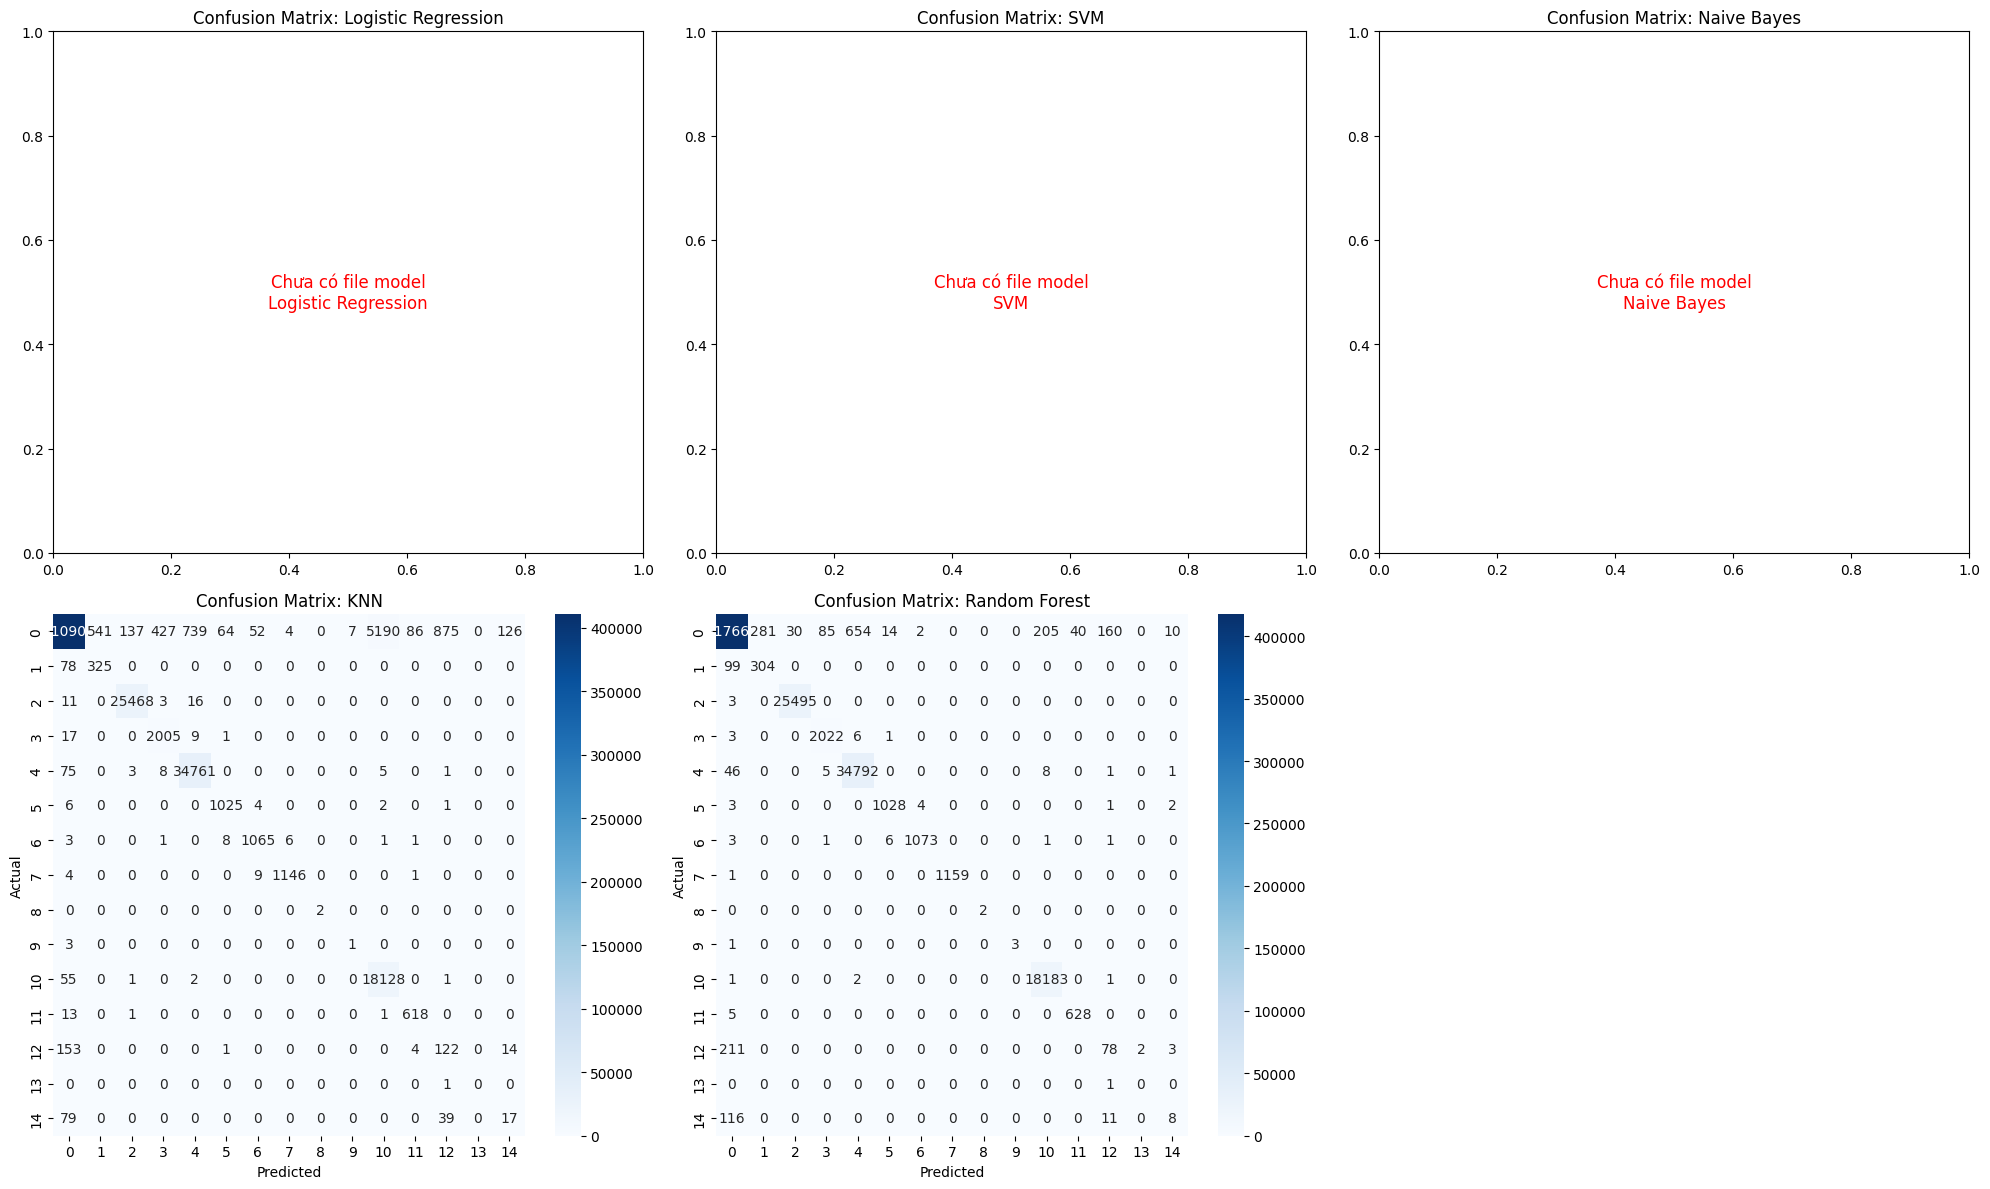


📊 BẢNG SO SÁNH KẾT QUẢ 5 MÔ HÌNH:


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,N/A,N/A,N/A,N/A
1,SVM,N/A,N/A,N/A,N/A
2,Naive Bayes,N/A,N/A,N/A,N/A
3,KNN,0.9824,0.9868,0.9824,0.9839
4,Random Forest,0.9960,0.9960,0.9960,0.9959


In [12]:
# ==========================================
# Phạm Quốc Huy - N23DVCN025 (TASK 2.5)
# 2.5 Huấn luyện mô hình (KNN, Random Forest), 
# Vẽ ma trận nhầm lẫn, So sánh mô hình & Kết luận.
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
from IPython.display import display # Thêm thư viện này để đảm bảo in bảng đẹp trong 1 cell

# Tạo thư mục lưu model và hình ảnh nếu chưa có
os.makedirs('../models', exist_ok=True)
os.makedirs('../data', exist_ok=True)

# Load lại dữ liệu từ folder processed của bạn
print("Đang load dữ liệu...")
X_train = np.load('../data/processed/X_train.npy')
y_train = np.load('../data/processed/y_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_test = np.load('../data/processed/y_test.npy')

# Hàm vẽ ma trận nhầm lẫn
def plot_confusion(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Dự đoán (Predicted)')
    plt.ylabel('Thực tế (Actual)')
    plt.savefig(save_path, bbox_inches='tight')
    plt.close()

# Khởi tạo 2 mô hình theo nhiệm vụ
models_huy = {
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

print("🚀 BẮT ĐẦU HUẤN LUYỆN VÀ ĐÁNH GIÁ...")
for name, model in models_huy.items():
    print(f"\n================ {name} ================")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("\n📊 CLASSIFICATION REPORT:")
    print(classification_report(y_test, y_pred, zero_division=0))
    
    # Vẽ CM và lưu
    cm_path = f"../data/confusion_{name.replace(' ', '_').lower()}.png"
    plot_confusion(y_test, y_pred, f"Confusion Matrix - {name}", cm_path)
    print(f"✅ Đã lưu Confusion Matrix tại: {cm_path}")
    
    # Lưu Model
    model_path = f"../models/{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(model, model_path)
    print(f"✅ Đã lưu mô hình tại: {model_path}")


# ==========================================
# PHẦN TỔNG HỢP VÀ SO SÁNH 5 MÔ HÌNH
# ==========================================
print("\n🚀 ĐANG TỔNG HỢP CONFUSION MATRICES CHO 5 MÔ HÌNH...")

model_files = {
    'Logistic Regression': '../models/logistic_regression.pkl',
    'SVM': '../models/svm.pkl',
    'Naive Bayes': '../models/naive_bayes.pkl',
    'KNN': '../models/knn.pkl',
    'Random Forest': '../models/random_forest.pkl'
}

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

summary_data = []

for i, (name, filepath) in enumerate(model_files.items()):
    try:
        model = joblib.load(filepath)
        y_pred = model.predict(X_test)
        
        # Vẽ CM
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f"Confusion Matrix: {name}")
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
        
        # Tính chỉ số cho bảng
        acc = accuracy_score(y_test, y_pred)
        p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
        summary_data.append({
            'Model': name, 'Accuracy': f"{acc:.4f}", 'Precision': f"{p:.4f}",
            'Recall': f"{r:.4f}", 'F1-Score': f"{f:.4f}"
        })
        
    except FileNotFoundError:
        axes[i].text(0.5, 0.5, f"Chưa có file model\n{name}", ha='center', va='center', fontsize=12, color='red')
        axes[i].set_title(f"Confusion Matrix: {name}")
        summary_data.append({'Model': name, 'Accuracy': "N/A", 'Precision': "N/A", 'Recall': "N/A", 'F1-Score': "N/A"})

axes[-1].axis('off')
plt.tight_layout()
plt.savefig("../data/all_models_confusion_matrices.png", bbox_inches='tight')
plt.show()

# In bảng phân tích
print("\n📊 BẢNG SO SÁNH KẾT QUẢ 5 MÔ HÌNH:")
df_compare = pd.DataFrame(summary_data)
display(df_compare)